# MFSEGO tutorial

In [1]:
import numpy as np
from matplotlib import pyplot as plt

from smt_optim.benchmarks.registry import get_problem

from smt_optim.core import Driver, ObjectiveConfig, ConstraintConfig, DriverConfig, Problem

from smt_optim.surrogate_models.smt import SmtAutoModel

from smt_optim.acquisition_strategies import MFSEGO

import scipy.optimize as so

## Unconstrained 1D optimization

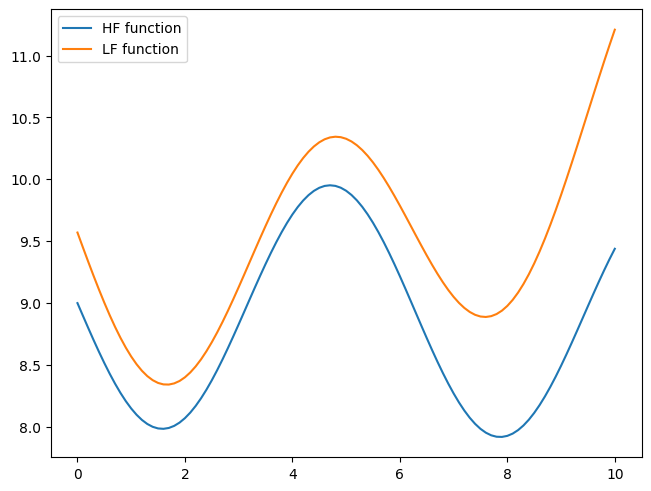

In [2]:
# high-fidelity function
def sasena2002_hf(x):
    return -np.sin(x) - np.exp(x / 100) + 10

# low-fidelity function
def sasena2002_lf(x):
    return sasena2002_hf(x) + 0.3 + 0.03 * (x - 3) ** 2

bounds = np.array([[0, 10]])

x_valid = np.linspace(bounds[:, 0], bounds[:, 1], 101)
y_hf = sasena2002_hf(x_valid)
y_lf = sasena2002_lf(x_valid)

fig, ax = plt.subplots(layout="constrained")
ax.plot(x_valid, y_hf, label="HF function")
ax.plot(x_valid, y_lf, label="LF function")

plt.legend()
plt.show()


In [3]:
obj_config = ObjectiveConfig(
    objective=[sasena2002_lf, sasena2002_hf],   # multi-fidelity functions must be given in sequential order
    type="minimize",
    surrogate=SmtAutoModel,
)


prob_definition = Problem(
    obj_configs=[obj_config],
    design_space=bounds,
    costs=[0.2, 1],                 # Set the cost of sampling each level
)


opt_config = DriverConfig(
    max_iter = 10,
    max_budget = 10,                # stopping criterion
    nt_init = 3,
    verbose = True,
    scaling = True,
    seed=42,
)

optimizer = Driver(prob_definition, opt_config, MFSEGO)

state = optimizer.optimize()

          iter         budget           fmin       fidelity        gp_time       acq_time
             1          4.400    7.98412e+00              1          0.129          0.168
             2          4.600    7.98412e+00              1          0.136          0.139
             3          5.800    7.98412e+00              2          0.155          0.180
             4          6.000    7.98412e+00              1          0.183          0.369
             5          7.200    7.91824e+00              2          0.177          0.272
             6          8.400    7.91824e+00              2          0.225          0.264
             7          9.600    7.91824e+00              2          0.175          0.236
             8         10.800    7.91824e+00              2          0.175          0.239


In [4]:
data = state.dataset.export_as_dict()
fidelity_masks = [(data["fidelity"] == lvl).ravel() for lvl in range(state.problem.num_fidelity)]
xt = [data["x"][fidelity_masks[lvl], 0] for lvl in range(state.problem.num_fidelity)]
yt = [data["obj"][fidelity_masks[lvl], 0] for lvl in range(state.problem.num_fidelity)]


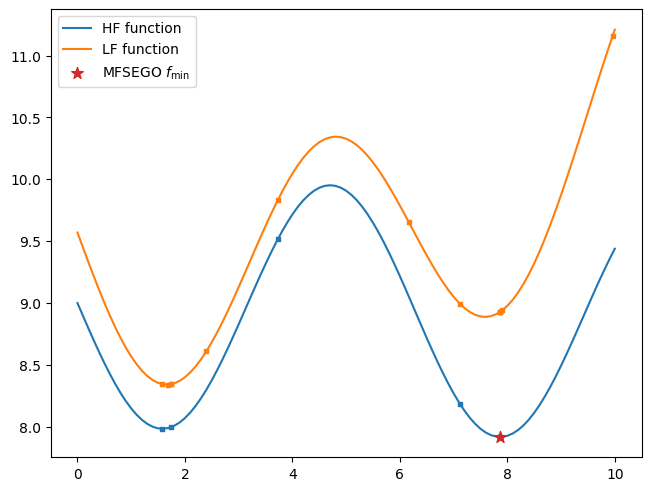

In [5]:
sample = state.get_best_sample()

fig, ax = plt.subplots(layout="constrained")
ax.plot(x_valid, y_hf, label="HF function")
ax.plot(x_valid, y_lf, label="LF function")

for lvl in reversed(range(2)):
    ax.scatter(xt[lvl], yt[lvl], 5, marker="s")

ax.scatter(sample.x, sample.obj, 75, marker="*", color="C3", zorder=20, label=r"MFSEGO $f_{\min}$")

plt.legend()
plt.show()

## Constrained 2D optimization)

### Importing a test function

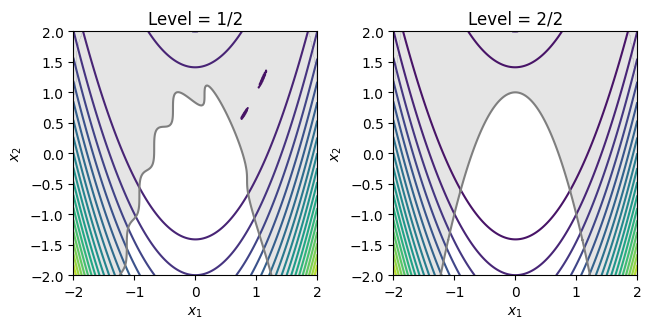

In [6]:
problem = get_problem("Rosenbrock")

X = np.linspace(problem.bounds[0, 0], problem.bounds[0, 1], 201)

XX, YY = np.meshgrid(X, X)

data = np.vstack((XX.ravel(), YY.ravel())).T
z = np.empty(data.shape[0])
c = np.empty(data.shape[0])

fig, ax = plt.subplots(1, 2, layout="constrained")

for lvl in range(2):

    ax[lvl].set_title(f"Level = {lvl+1}/2")

    for i in range(data.shape[0]):
        z[i] = problem.objective[lvl](data[i, :])
        c[i] = problem.constraints[0][lvl](data[i, :])

    Z = z.reshape(XX.shape)
    C = c.reshape(XX.shape)

    ax[lvl].contour(XX, YY, Z, levels=20)

    ax[lvl].contourf(XX, YY, np.where(C <= 0, np.nan, C), levels=0, colors="C7", alpha=0.20)
    ax[lvl].contour(XX, YY, C, levels=[0], colors="C7")

    ax[lvl].set_xlabel(r"$x_1$")
    ax[lvl].set_ylabel(r"$x_2$")
    ax[lvl].set_aspect("equal")

plt.show()

### MFSEGO Configuration

In [7]:
obj_config = ObjectiveConfig(
    problem.objective,
    type="minimize",
    surrogate=SmtAutoModel,

)

# configure the constraint
cstr_config = ConstraintConfig(
    problem.constraints[0],
    type="less",                    # set the constraint type (less, greater or equal)
    value=0.0,                      # g(x) <= 0
    surrogate=SmtAutoModel,               # set which GP to model this constraint
)


prob_definition = Problem(
    obj_configs=[obj_config],
    design_space=problem.bounds,
    costs=[0.2, 1],                 # Set the cost of sampling each level
    cstr_configs=[cstr_config],
)


opt_config = DriverConfig(
    max_iter = 30,
    max_budget = 10,                # stopping criterion
    nt_init = 3,
    verbose = True,
    scaling = True,
    seed=42,
)

optimizer = Driver(prob_definition, opt_config, MFSEGO)

state = optimizer.optimize()

          iter         budget           fmin       fidelity        gp_time       acq_time
             1          4.400    8.01358e+02              1          0.858          0.697
             2          4.600    8.01358e+02              1          0.841          1.418
             3          4.800    8.01358e+02              1          0.827          0.533
             4          5.000    8.01358e+02              1          0.839          0.559
             5          5.200    8.01358e+02              1          0.811          3.180
             6          5.400    8.01358e+02              1          0.926          4.314
             7          5.600    8.01358e+02              1          0.853          5.062
             8          5.800    8.01358e+02              1          0.862          2.135
             9          6.000    8.01358e+02              1          0.842          4.839
            10          6.200    8.01358e+02              1          0.854          3.671
          

### Validation with SLSQP
SLSQP is a mono-fidelity gradient-based solver.

In [8]:
cstrs = [{
        "fun": lambda x, f=problem.constraints[0][-1]: -f(x),
        "type": "ineq",
        }]

res = so.minimize(problem.objective[-1], [0.5, 0.5], bounds=problem.bounds, constraints=cstrs, method="SLSQP", tol=1e-15)

print(res)

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 0.17848414871339022
           x: [ 5.777e-01  3.325e-01]
         nit: 6
         jac: [-5.631e-01 -2.437e-01]
        nfev: 19
        njev: 6
 multipliers: [ 4.873e-01]


best sample = 
======= sample data =======
x =             [0.47414851 0.23779338]
obj =           [0.29335892]
cstr =          [-0.1562865]
eval_time =     [9.93983122e-07 6.25004759e-07]
------- meta data -------
iter =     25
budget =     10.2
fidelity =     1



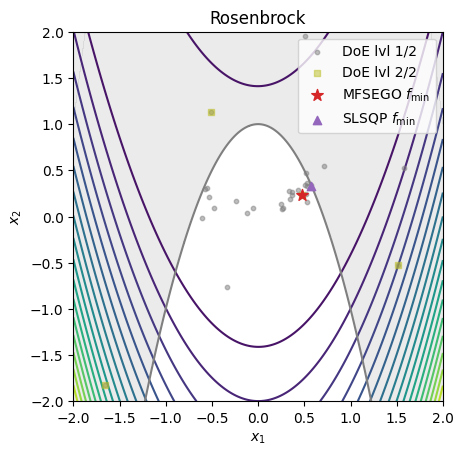

In [9]:
data_x = []
for lvl in range(state.problem.num_fidelity):
    samples = state.dataset.get_by_fidelity(lvl)
    data_x.append(np.empty((len(samples), state.problem.num_dim)))
    for idx, s in enumerate(samples):
        data_x[lvl][idx, :] = s.x

sample = state.get_best_sample(ctol=1e-4)
print(f"best sample = \n{sample}")

X = np.linspace(problem.bounds[0, 0], problem.bounds[0, 1], 201)

XX, YY = np.meshgrid(X, X)

data = np.vstack((XX.ravel(), YY.ravel())).T
z = np.empty(data.shape[0])
c = np.empty(data.shape[0])

for i in range(data.shape[0]):
    z[i] = problem.objective[-1](data[i, :])
    c[i] = problem.constraints[0][-1](data[i, :])

Z = z.reshape(XX.shape)
C = c.reshape(XX.shape)

fig, ax = plt.subplots()

ax.set_title(problem.name)

ax.contour(XX, YY, Z, levels=20)

ax.contourf(XX, YY, np.where(C <= 0, np.nan, C), levels=0, colors="C7", alpha=0.15)
ax.contour(XX, YY, C, levels=[0], colors="C7")

ax.scatter(data_x[0][:, 0], data_x[0][:, 1], 10, color="C7", marker="o", alpha=0.5, label="DoE lvl 1/2", zorder=10)
ax.scatter(data_x[1][:, 0], data_x[1][:, 1], 20, color="C8", marker="s", alpha=0.5, label="DoE lvl 2/2", zorder=20)

ax.scatter(sample.x[0], sample.x[1], 75, c="C3", marker="*", label=r"MFSEGO $f_{\min}$", zorder=30)
ax.scatter(res.x[0], res.x[1], c="C4", marker="^", label=r"SLSQP $f_{\min}$", zorder=20)

ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")

ax.legend()
ax.set_aspect("equal")
plt.show()